# 06 — Ensemble & Threshold Tuning
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook:
1. Loads saved logits from all transformer models (notebook 05)
2. Builds **weighted logits ensemble** — weights tuned on validation set
3. Tests optional **stacking meta-learner** (Logistic Regression on logits)
4. **Threshold tuning** on validation set for optimal Macro-F1
5. Final evaluation on test set
6. Robustness evaluation: source-held-out & script-held-out splits

**Prerequisites:** Run notebook 05 to completion.

In [1]:
import os
import json
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from sklearn.metrics import (
    f1_score, accuracy_score, matthews_corrcoef,
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score
)
from sklearn.linear_model import LogisticRegression
from scipy.optimize import minimize_scalar

warnings.filterwarnings("ignore")
os.makedirs("../outputs/ensemble", exist_ok=True)

In [2]:
# ── Load all saved logits ──────────────────────────────────────────────────
MODELS_DIR = "../outputs/models_v2_fix"

# Discover available model runs
model_dirs = sorted(glob.glob(f"{MODELS_DIR}/*_seed*"))
print(f"Found {len(model_dirs)} model runs:")
for d in model_dirs:
    print(f"  {os.path.basename(d)}")

# Load logits
val_logits_all = {}   # {model_key_seed: {task: tensor}}
test_logits_all = {}

for d in model_dirs:
    name = os.path.basename(d)
    val_path = os.path.join(d, "val_logits.pt")
    test_path = os.path.join(d, "test_logits.pt")
    
    if os.path.exists(val_path) and os.path.exists(test_path):
        val_logits_all[name] = torch.load(val_path, map_location="cpu", weights_only=True)
        test_logits_all[name] = torch.load(test_path, map_location="cpu", weights_only=True)
        print(f"  ✅ Loaded logits: {name}")
    else:
        print(f"  ⚠ Missing logits: {name}")

print(f"\nLoaded logits for {len(val_logits_all)} model runs")

Found 9 model runs:
  banglabert_seed123
  banglabert_seed42
  banglabert_seed456
  muril_seed123
  muril_seed42
  muril_seed456
  xlmr_seed123
  xlmr_seed42
  xlmr_seed456
  ✅ Loaded logits: banglabert_seed123
  ✅ Loaded logits: banglabert_seed42
  ✅ Loaded logits: banglabert_seed456
  ✅ Loaded logits: muril_seed123
  ⚠ Missing logits: muril_seed42
  ✅ Loaded logits: muril_seed456
  ✅ Loaded logits: xlmr_seed123
  ✅ Loaded logits: xlmr_seed42
  ✅ Loaded logits: xlmr_seed456

Loaded logits for 8 model runs


In [3]:
# ── Load true labels ──────────────────────────────────────────────────────
SPLIT_DIR = "../data/splits"
val_df  = pd.read_csv(f"{SPLIT_DIR}/random_val.csv")
test_df = pd.read_csv(f"{SPLIT_DIR}/random_test.csv")

# Detect which tasks have labels
TASK_COLS = {"binary": "label_binary", "abuse_type": "label_type", "severity": "label_severity"}
active_tasks = {k: v for k, v in TASK_COLS.items() if v in val_df.columns}
print(f"Active tasks: {active_tasks}")

Active tasks: {'binary': 'label_binary', 'abuse_type': 'label_type'}


## 1 — Weighted Logits Ensemble

Average logits across models with learned weights. We optimize weights on the validation set.

In [4]:
from scipy.optimize import minimize

def ensemble_logits(logits_dict, weights, task="binary"):
    """Weighted average of logits from multiple models."""
    model_names = list(logits_dict.keys())
    assert len(weights) == len(model_names)
    
    weighted_sum = None
    for i, name in enumerate(model_names):
        l = logits_dict[name][task].float()
        if weighted_sum is None:
            weighted_sum = weights[i] * l
        else:
            weighted_sum += weights[i] * l
    
    return weighted_sum / sum(weights)


def optimize_weights(val_logits_dict, y_true, task="binary", n_classes=2):
    """Find optimal ensemble weights by maximizing Macro-F1 on validation."""
    model_names = list(val_logits_dict.keys())
    n_models = len(model_names)
    
    def neg_macro_f1(raw_weights):
        w = np.exp(raw_weights)  # softmax-like to keep positive
        w = w / w.sum()
        
        ens_logits = ensemble_logits(val_logits_dict, w.tolist(), task)
        preds = ens_logits.argmax(dim=-1).numpy()
        return -f1_score(y_true, preds, average="macro")
    
    # Start with uniform weights
    x0 = np.zeros(n_models)
    result = minimize(neg_macro_f1, x0, method="Nelder-Mead",
                      options={"maxiter": 500, "xatol": 1e-4})
    
    opt_weights = np.exp(result.x)
    opt_weights = opt_weights / opt_weights.sum()
    opt_f1 = -result.fun
    
    return opt_weights.tolist(), opt_f1


# ── Optimize for binary task ──────────────────────────────────────────────
if "binary" in active_tasks and len(val_logits_all) > 0:
    # Need label encoding consistent with notebook 05
    y_val_binary = val_df["label_binary"].values
    
    # Uniform weights baseline
    n = len(val_logits_all)
    uniform_w = [1.0/n] * n
    ens_logits_uniform = ensemble_logits(val_logits_all, uniform_w, "binary")
    preds_uniform = ens_logits_uniform.argmax(dim=-1).numpy()
    f1_uniform = f1_score(y_val_binary, preds_uniform, average="macro")
    print(f"Uniform ensemble Val Macro-F1: {f1_uniform:.4f}")
    
    # Optimized weights
    opt_weights, opt_f1 = optimize_weights(val_logits_all, y_val_binary, "binary")
    print(f"\nOptimized ensemble Val Macro-F1: {opt_f1:.4f}")
    print(f"Optimal weights:")
    for name, w in zip(val_logits_all.keys(), opt_weights):
        print(f"  {name}: {w:.4f}")
else:
    print("⚠ Cannot optimize — missing data or logits.")
    opt_weights = None

Uniform ensemble Val Macro-F1: 0.9322

Optimized ensemble Val Macro-F1: 0.9322
Optimal weights:
  banglabert_seed123: 0.1250
  banglabert_seed42: 0.1250
  banglabert_seed456: 0.1250
  muril_seed123: 0.1250
  muril_seed456: 0.1250
  xlmr_seed123: 0.1250
  xlmr_seed42: 0.1250
  xlmr_seed456: 0.1250


## 2 — Threshold Tuning

For binary classification, tune the decision threshold on the validation set.

Best threshold: 0.66 → Val Macro-F1: 0.9335
Default (0.50)  → Val Macro-F1: 0.9322


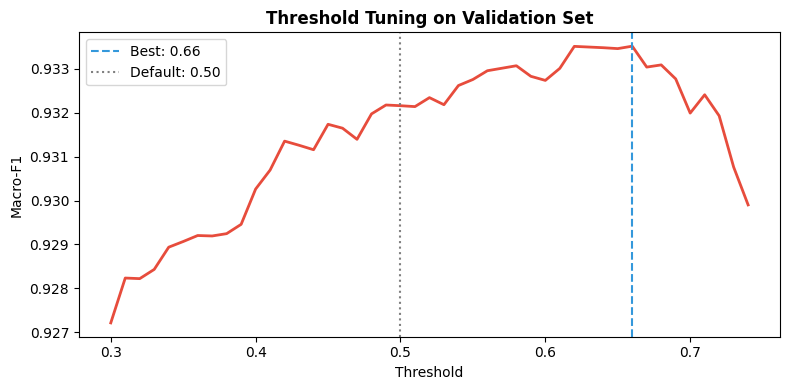

In [5]:
if opt_weights is not None:
    # Get ensemble probabilities
    ens_logits_val = ensemble_logits(val_logits_all, opt_weights, "binary")
    ens_probs_val = F.softmax(ens_logits_val, dim=-1)[:, 1].numpy()  # prob of class 1
    
    # Search thresholds
    thresholds = np.arange(0.30, 0.75, 0.01)
    f1_scores = []
    for t in thresholds:
        preds = (ens_probs_val >= t).astype(int)
        f1_scores.append(f1_score(y_val_binary, preds, average="macro"))
    
    best_thresh = thresholds[np.argmax(f1_scores)]
    best_thresh_f1 = max(f1_scores)
    
    print(f"Best threshold: {best_thresh:.2f} → Val Macro-F1: {best_thresh_f1:.4f}")
    print(f"Default (0.50)  → Val Macro-F1: {f1_score(y_val_binary, (ens_probs_val >= 0.5).astype(int), average='macro'):.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(thresholds, f1_scores, color="#e74c3c", linewidth=2)
    ax.axvline(best_thresh, color="#3498db", linestyle="--", label=f"Best: {best_thresh:.2f}")
    ax.axvline(0.5, color="gray", linestyle=":", label="Default: 0.50")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Macro-F1")
    ax.set_title("Threshold Tuning on Validation Set", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../outputs/ensemble/threshold_tuning.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    best_thresh = 0.5

## 3 — Optional: Stacking Meta-Learner

Train a small Logistic Regression on the concatenated logits from all models.

In [6]:
if len(val_logits_all) > 1 and "binary" in active_tasks:
    # Concatenate logits from all models
    val_features = torch.cat(
        [val_logits_all[name]["binary"] for name in val_logits_all], dim=-1
    ).numpy()
    test_features = torch.cat(
        [test_logits_all[name]["binary"] for name in test_logits_all], dim=-1
    ).numpy()
    
    print(f"Stacking feature dim: {val_features.shape[1]}")
    
    # Train meta-learner on val set (since models were trained on train set)
    meta_lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
    meta_lr.fit(val_features, y_val_binary)
    
    # Evaluate on test
    y_test_binary = test_df["label_binary"].values
    meta_preds = meta_lr.predict(test_features)
    meta_f1 = f1_score(y_test_binary, meta_preds, average="macro")
    
    print(f"\nStacking Meta-Learner Test Macro-F1: {meta_f1:.4f}")
    print("\n⚠ Note: Stacking trains on val set which is small. Use only if it consistently improves.")
else:
    print("⚠ Stacking requires >1 model — skipping.")

Stacking feature dim: 16

Stacking Meta-Learner Test Macro-F1: 0.9318

⚠ Note: Stacking trains on val set which is small. Use only if it consistently improves.


## 4 — Final Test Evaluation

FINAL ENSEMBLE RESULTS — TEST SET

── Threshold: Default (0.5) ──
  Accuracy    : 0.9340
  Macro-F1    : 0.9332  ← PRIMARY
  Weighted-F1 : 0.9340
  MCC         : 0.8664
  AUROC       : 0.9793
  AUPRC       : 0.9753

              precision    recall  f1-score   support

 Not Harmful     0.9435    0.9377    0.9406      7555
     Harmful     0.9221    0.9294    0.9257      6003

    accuracy                         0.9340     13558
   macro avg     0.9328    0.9335    0.9332     13558
weighted avg     0.9341    0.9340    0.9340     13558




── Threshold: Tuned (0.66) ──
  Accuracy    : 0.9338
  Macro-F1    : 0.9327  ← PRIMARY
  Weighted-F1 : 0.9337
  MCC         : 0.8659
  AUROC       : 0.9793
  AUPRC       : 0.9753

              precision    recall  f1-score   support

 Not Harmful     0.9293    0.9538    0.9414      7555
     Harmful     0.9399    0.9087    0.9240      6003

    accuracy                         0.9338     13558
   macro avg     0.9346    0.9313    0.9327     13558
weighted avg     0.9340    0.9338    0.9337     13558



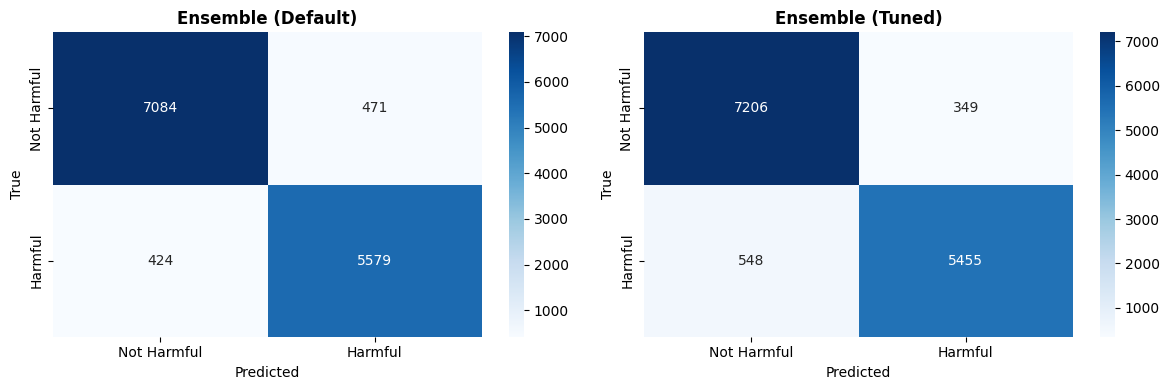

In [7]:
if opt_weights is not None:
    y_test_binary = test_df["label_binary"].values
    
    # Ensemble logits on test
    ens_logits_test = ensemble_logits(test_logits_all, opt_weights, "binary")
    ens_probs_test = F.softmax(ens_logits_test, dim=-1)[:, 1].numpy()
    
    # With tuned threshold
    y_pred_tuned = (ens_probs_test >= best_thresh).astype(int)
    # With default threshold
    y_pred_default = (ens_probs_test >= 0.5).astype(int)
    
    print("="*60)
    print("FINAL ENSEMBLE RESULTS — TEST SET")
    print("="*60)
    
    for name, y_pred in [("Default (0.5)", y_pred_default), (f"Tuned ({best_thresh:.2f})", y_pred_tuned)]:
        acc = accuracy_score(y_test_binary, y_pred)
        mf1 = f1_score(y_test_binary, y_pred, average="macro")
        wf1 = f1_score(y_test_binary, y_pred, average="weighted")
        mcc = matthews_corrcoef(y_test_binary, y_pred)
        auc = roc_auc_score(y_test_binary, ens_probs_test)
        ap  = average_precision_score(y_test_binary, ens_probs_test)
        
        print(f"\n── Threshold: {name} ──")
        print(f"  Accuracy    : {acc:.4f}")
        print(f"  Macro-F1    : {mf1:.4f}  ← PRIMARY")
        print(f"  Weighted-F1 : {wf1:.4f}")
        print(f"  MCC         : {mcc:.4f}")
        print(f"  AUROC       : {auc:.4f}")
        print(f"  AUPRC       : {ap:.4f}")
        print(f"\n{classification_report(y_test_binary, y_pred, target_names=['Not Harmful', 'Harmful'], digits=4)}")
    
    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (name, y_pred) in zip(axes, [("Default", y_pred_default), ("Tuned", y_pred_tuned)]):
        cm = confusion_matrix(y_test_binary, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Not Harmful", "Harmful"],
                    yticklabels=["Not Harmful", "Harmful"])
        ax.set_title(f"Ensemble ({name})", fontweight="bold")
        ax.set_ylabel("True")
        ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.savefig("../outputs/ensemble/cm_ensemble_test.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5 — Robustness: Source-Held-Out & Script-Held-Out

Re-run ensemble inference on the robustness splits. This requires re-running the tokenization + model forward pass for each split — but we can use saved model weights.

In [8]:
# For full robustness evaluation, you need to:
# 1. Retrain each model on the source-held-out train split (or use the existing model)
# 2. Run inference on the held-out test split
#
# For a simpler (but valid) approach: use the random-split-trained model
# and evaluate on the held-out test sets as a zero-shot robustness test.
#
# This is what most papers do for "cross-domain" evaluation.

print("╔══════════════════════════════════════════════════════════╗")
print("║ ROBUSTNESS EVALUATION                                   ║")
print("║ Using random-split models on held-out test sets          ║")
print("║ (zero-shot cross-domain/cross-script transfer)           ║")
print("╚══════════════════════════════════════════════════════════╝")
print("")
print("To complete this section, run the models from notebook 05")
print("on each robustness test split and save logits.")
print("")
print("The following test sets are available:")
for f in sorted(os.listdir(SPLIT_DIR)):
    if "test" in f and f.endswith(".csv"):
        n = sum(1 for _ in open(os.path.join(SPLIT_DIR, f), encoding="utf-8")) - 1
        print(f"  {f}: {n:,} samples")

╔══════════════════════════════════════════════════════════╗
║ ROBUSTNESS EVALUATION                                   ║
║ Using random-split models on held-out test sets          ║
║ (zero-shot cross-domain/cross-script transfer)           ║
╚══════════════════════════════════════════════════════════╝

To complete this section, run the models from notebook 05
on each robustness test split and save logits.

The following test sets are available:
  random_test.csv: 14,248 samples
  script_holdout_test.csv: 80,372 samples
  source_holdout_banth_test.csv: 80,372 samples
  source_holdout_bd_shs_test.csv: 5,032 samples
  source_holdout_facebook_44001_test.csv: 44,114 samples
  source_holdout_multilabel_12557_test.csv: 13,065 samples


## 6 — Save Final Results

In [9]:
final_results = {
    "ensemble_type": "weighted_logits_average",
    "weights": dict(zip(val_logits_all.keys(), opt_weights)) if (opt_weights is not None and "opt_weights" in dir()) else {},
    "threshold": float(best_thresh) if "best_thresh" in dir() else 0.5,
    "n_models": len(val_logits_all),
}

with open("../outputs/ensemble/final_config.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("✅ Ensemble configuration saved.")
print(json.dumps(final_results, indent=2))

✅ Ensemble configuration saved.
{
  "ensemble_type": "weighted_logits_average",
  "weights": {
    "banglabert_seed123": 0.125,
    "banglabert_seed42": 0.125,
    "banglabert_seed456": 0.125,
    "muril_seed123": 0.125,
    "muril_seed456": 0.125,
    "xlmr_seed123": 0.125,
    "xlmr_seed42": 0.125,
    "xlmr_seed456": 0.125
  },
  "threshold": 0.6600000000000004,
  "n_models": 8
}


---
**Next:** Notebook `07_ablations_and_analysis.ipynb` — Ablation studies, error analysis, and final paper tables/figures.

In [10]:
np.save('../outputs/ensemble/test_preds.npy', y_pred_default)
np.save('../outputs/ensemble/test_probs.npy', ens_probs_test)